In [1]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.utils import check_random_state

from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_regression, mutual_info_classif, RFE
from sklearn.decomposition import PCA, KernelPCA
from sklearn.manifold import TSNE, Isomap

from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.metrics import (
    mean_absolute_error, root_mean_squared_error, r2_score,
    accuracy_score, f1_score, roc_auc_score, confusion_matrix
)

import matplotlib.pyplot as plt

import umap


c:\Users\IronSmail\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [15]:
def top_loadings_pca(pca: PCA, feature_names, top_n=8):
    # pca.components_: (n_components, n_features)
    res = []
    for i, comp in enumerate(pca.components_):
        idx = np.argsort(np.abs(comp))[::-1][:top_n]
        res.append((i, list(zip(feature_names[idx], comp[idx]))))
    return res

In [16]:
def build_preprocessor(X: pd.DataFrame):
    cat_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
    num_cols = [c for c in X.columns if c not in cat_cols]

    numeric_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    categorical_pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ])

    preprocessor = ColumnTransformer([
        ("num", numeric_pipe, num_cols),
        ("cat", categorical_pipe, cat_cols)
    ], remainder="drop", verbose_feature_names_out=True)

    return preprocessor

In [17]:
def regression_metrics(y_true, y_pred):
    rmse = root_mean_squared_error(y_true, y_pred)
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": rmse,
        "R2": r2_score(y_true, y_pred)
    }

def classification_metrics(y_true, y_pred, y_proba=None):
    out = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred)
    }
    if y_proba is not None and len(np.unique(y_true)) == 2:
        out["ROC_AUC"] = roc_auc_score(y_true, y_proba)
    return out

In [18]:
def get_feature_names(preprocessor: ColumnTransformer):
    return np.array(preprocessor.get_feature_names_out())

In [19]:
cars = pd.read_csv("../data/carsEDA.csv")

X = cars.drop(columns=["price_usd"])
y = cars["price_usd"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

preprocessor = build_preprocessor(X_train)

X_train_p = preprocessor.fit_transform(X_train)
X_test_p  = preprocessor.transform(X_test)

feature_names = get_feature_names(preprocessor)
print("X_train_p shape:", X_train_p.shape)

X_train_p shape: (22703, 149)


In [20]:
reg_model = Ridge(alpha=1.0, random_state=42)

In [21]:
def evaluate_regression_reducers(
    X_train_p, X_test_p, y_train, y_test, feature_names,
    k=20,
    fit_sample=5000,          
    do_tsne=False,           
    random_state=42
):
    rng = check_random_state(random_state)

    reducers = {}
    reducers["Baseline(no reduction)"] = None
    reducers["VarianceThreshold"] = VarianceThreshold(threshold=0.0)
    reducers[f"SelectKBest(f_regression, k={k})"] = SelectKBest(
        score_func=f_regression, k=min(k, X_train_p.shape[1])
    )
    reducers[f"RFE(Ridge, k={k})"] = RFE(
        estimator=Ridge(alpha=1.0, random_state=42),
        n_features_to_select=min(k, X_train_p.shape[1]),
        step=0.1 
    )

    reducers[f"PCA(k={k})"] = PCA(
        n_components=min(k, X_train_p.shape[1]),
        random_state=42,
        svd_solver="randomized" 
    )

    reducers[f"KernelPCA-poly(k={k})"] = KernelPCA(n_components=k, kernel="poly", random_state=42)
    reducers[f"KernelPCA-rbf(k={k})"]  = KernelPCA(n_components=k, kernel="rbf", random_state=42)
    reducers[f"KernelPCA-sigmoid(k={k})"] = KernelPCA(n_components=k, kernel="sigmoid", random_state=42)

    reducers[f"Isomap(k={k})"] = Isomap(n_components=k, n_neighbors=10)

    reducers[f"UMAP(k={k})"] = umap.UMAP(
        n_components=k, n_neighbors=15, min_dist=0.1,
        random_state=42,
        n_jobs=-1,        
        low_memory=True   
    )

    if do_tsne:
        reducers["t-SNE(2D)"] = TSNE(
            n_components=2, perplexity=30, init="pca",
            learning_rate="auto", random_state=42
        )

    results = []
    selected_info = {}

    n_fit = min(fit_sample, X_train_p.shape[0])
    fit_idx = rng.choice(X_train_p.shape[0], size=n_fit, replace=False)

    heavy_names = ("KernelPCA", "Isomap", "UMAP") 

    for name, red in reducers.items():
        if red is None:
            Xtr, Xte = X_train_p, X_test_p

        elif isinstance(red, TSNE):
            X_all = np.vstack([X_train_p[fit_idx], X_test_p[:min(len(X_test_p), n_fit)]])
            X_all_emb = red.fit_transform(X_all)
            Xtr = X_all_emb[:len(X_train_p[fit_idx])]
            Xte = X_all_emb[len(X_train_p[fit_idx]):]

        else:
            fit_on_subset = any(name.startswith(h) for h in heavy_names)

            if fit_on_subset:
                X_fit = X_train_p[fit_idx]
                y_fit = np.asarray(y_train)[fit_idx]
            else:
                X_fit = X_train_p
                y_fit = y_train

            try:
                red.fit(X_fit, y_fit)
            except TypeError:
                red.fit(X_fit)

            Xtr = red.transform(X_train_p)
            Xte = red.transform(X_test_p)

            if hasattr(red, "get_support"):
                mask = red.get_support()
                selected_info[name] = feature_names[mask].tolist()

            if isinstance(red, PCA):
                selected_info[name] = {
                    "explained_variance_ratio": red.explained_variance_ratio_.tolist(),
                    "top_loadings": top_loadings_pca(red, feature_names, top_n=8)
                }

        model = Ridge(alpha=1.0, solver="sag", max_iter=3000, random_state=42)
        model.fit(Xtr, y_train)
        pred = model.predict(Xte)

        mets = regression_metrics(y_test, pred)
        results.append({"Method": name, **mets, "ReducedDim": Xtr.shape[1]})

    return pd.DataFrame(results).sort_values("RMSE"), selected_info

In [22]:
reg_results, reg_selected = evaluate_regression_reducers(
    X_train_p, X_test_p, y_train, y_test, feature_names, k=20
)

c:\Users\IronSmail\AppData\Local\Programs\Python\Python313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [23]:
for key in reg_selected:
    if isinstance(reg_selected[key], list):
        print("\n", key)
        print("Selected features (first 40):", reg_selected[key][:40])

pca_key = [k for k in reg_selected.keys() if k.startswith("PCA")][0]
print("\n", pca_key)
print("Explained variance ratio:", reg_selected[pca_key]["explained_variance_ratio"])

for comp_id, feats in reg_selected[pca_key]["top_loadings"][:3]:
    print(f"\nComponent {comp_id} top loadings:")
    for f, w in feats:
        print(f"  {f}: {w:.4f}")


 VarianceThreshold
Selected features (first 40): ['num__Unnamed: 0', 'num__odometer_value', 'num__engine_capacity', 'num__number_of_photos', 'num__up_counter', 'num__duration_listed', 'num__car_age', 'num__mileage', 'num__popularity_rank', 'num__manuf_rank', 'cat__manufacturer_name_Alfa Romeo', 'cat__manufacturer_name_Audi', 'cat__manufacturer_name_BMW', 'cat__manufacturer_name_Chevrolet', 'cat__manufacturer_name_Chrysler', 'cat__manufacturer_name_Citroen', 'cat__manufacturer_name_Daewoo', 'cat__manufacturer_name_Dodge', 'cat__manufacturer_name_Fiat', 'cat__manufacturer_name_Ford', 'cat__manufacturer_name_Honda', 'cat__manufacturer_name_Hyundai', 'cat__manufacturer_name_Kia', 'cat__manufacturer_name_Lexus', 'cat__manufacturer_name_Mazda', 'cat__manufacturer_name_Mercedes-Benz', 'cat__manufacturer_name_Mitsubishi', 'cat__manufacturer_name_Nissan', 'cat__manufacturer_name_Opel', 'cat__manufacturer_name_Other', 'cat__manufacturer_name_Peugeot', 'cat__manufacturer_name_Renault', 'cat__man

# Классификация

In [24]:
smoke = pd.read_csv("../data/smokeEDA.csv")

y = smoke["Fire Alarm"].copy()
X = smoke.drop(columns=["Fire Alarm"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

preprocessor = build_preprocessor(X_train)
X_train_p = preprocessor.fit_transform(X_train)
X_test_p  = preprocessor.transform(X_test)

feature_names = get_feature_names(preprocessor)
print("X_train_p shape:", X_train_p.shape)
print("Class balance:", y.value_counts(normalize=True))

X_train_p shape: (34172, 12)
Class balance: Fire Alarm
True     0.719373
False    0.280627
Name: proportion, dtype: float64


In [25]:
clf_model = LogisticRegression(max_iter=5000, solver="saga", random_state=42)

In [26]:
def evaluate_classification_reducers(
    X_train_p, X_test_p, y_train, y_test, feature_names,
    k=20,
    fit_sample=5000,
    do_tsne=False,
    random_state=42
):
    rng = check_random_state(random_state)

    reducers = {}
    reducers["Baseline(no reduction)"] = None
    reducers["VarianceThreshold"] = VarianceThreshold(threshold=0.0)

    reducers[f"SelectKBest(mutual_info, k={k})"] = SelectKBest(
        score_func=mutual_info_classif,
        k=min(k, X_train_p.shape[1])
    )

    reducers[f"RFE(LogReg, k={k})"] = RFE(
        estimator=LogisticRegression(
            max_iter=2000, solver="saga", tol=1e-3, random_state=42
        ),
        n_features_to_select=min(k, X_train_p.shape[1]),
        step=0.1
    )

    reducers[f"PCA(k={k})"] = PCA(
        n_components=min(k, X_train_p.shape[1]),
        random_state=42,
        svd_solver="randomized"
    )

    reducers[f"KernelPCA-poly(k={k})"] = KernelPCA(n_components=k, kernel="poly", random_state=42)
    reducers[f"KernelPCA-rbf(k={k})"]  = KernelPCA(n_components=k, kernel="rbf", random_state=42)
    reducers[f"KernelPCA-sigmoid(k={k})"] = KernelPCA(n_components=k, kernel="sigmoid", random_state=42)

    reducers[f"Isomap(k={k})"] = Isomap(n_components=k, n_neighbors=10)

    reducers[f"UMAP(k={k})"] = umap.UMAP(
        n_components=k, n_neighbors=15, min_dist=0.1,
        random_state=42, n_jobs=-1, low_memory=True
    )

    if do_tsne:
        reducers["t-SNE(2D)"] = TSNE(
            n_components=2, perplexity=30, init="pca",
            learning_rate="auto", random_state=42
        )

    results = []
    selected_info = {}

    y_train_np = np.asarray(y_train)

    n_fit = min(fit_sample, X_train_p.shape[0])
    fit_idx = rng.choice(X_train_p.shape[0], size=n_fit, replace=False)

    heavy_prefix = ("KernelPCA", "Isomap", "UMAP") 

    for name, red in reducers.items():
        if red is None:
            Xtr, Xte = X_train_p, X_test_p

        elif isinstance(red, TSNE):
            X_all = np.vstack([X_train_p[fit_idx], X_test_p[:min(len(X_test_p), n_fit)]])
            X_all_emb = red.fit_transform(X_all)
            Xtr = X_all_emb[:len(fit_idx)]
            Xte = X_all_emb[len(fit_idx):]

        else:
            fit_on_subset = any(name.startswith(p) for p in heavy_prefix) or name.startswith("SelectKBest(mutual_info")
            if fit_on_subset:
                X_fit = X_train_p[fit_idx]
                y_fit = y_train_np[fit_idx]
            else:
                X_fit = X_train_p
                y_fit = y_train_np

            try:
                red.fit(X_fit, y_fit)
            except TypeError:
                red.fit(X_fit)

            Xtr = red.transform(X_train_p)
            Xte = red.transform(X_test_p)

            if hasattr(red, "get_support"):
                mask = red.get_support()
                selected_info[name] = feature_names[mask].tolist()

            if isinstance(red, PCA):
                selected_info[name] = {
                    "explained_variance_ratio": red.explained_variance_ratio_.tolist(),
                    "top_loadings": top_loadings_pca(red, feature_names, top_n=8)
                }

        model = LogisticRegression(
            max_iter=2000, solver="saga", tol=1e-3, random_state=42
        )
        model.fit(Xtr, y_train)

        pred = model.predict(Xte)
        proba = model.predict_proba(Xte)[:, 1] if hasattr(model, "predict_proba") else None
        mets = classification_metrics(y_test, pred, proba)

        results.append({"Method": name, **mets, "ReducedDim": Xtr.shape[1]})

    return pd.DataFrame(results).sort_values(["F1", "Accuracy"], ascending=False), selected_info

clf_results, clf_selected = evaluate_classification_reducers(
    X_train_p, X_test_p, y_train, y_test, feature_names, k=20
)

clf_results

c:\Users\IronSmail\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\manifold\_isomap.py:360: UserWarning: The number of connected components of the neighbors graph is 2 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
c:\Users\IronSmail\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\sparse\_index.py:168: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])
c:\Users\IronSmail\AppData\Local\Programs\Python\Python313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


,Method,Accuracy,F1,ROC_AUC,ReducedDim
0,Baseline(no reduction),0.999532,0.999675,0.999996,12
1,VarianceThreshold,0.999532,0.999675,0.999996,12
2,"SelectKBest(mutual_info, k=20)",0.999532,0.999675,0.999996,12
3,"RFE(LogReg, k=20)",0.999532,0.999675,0.999996,12
4,PCA(k=20),0.999532,0.999675,0.999996,12
5,KernelPCA-poly(k=20),0.998712,0.999105,0.999831,20
9,UMAP(k=20),0.998127,0.998700,0.999339,20
8,Isomap(k=20),0.998010,0.998618,0.999117,20
6,KernelPCA-rbf(k=20),0.997659,0.998375,0.999794,20
7,KernelPCA-sigmoid(k=20),0.995903,0.997157,0.999520,20


In [27]:
for key in clf_selected:
    if isinstance(clf_selected[key], list):
        print("\n", key)
        print("Selected features (first 40):", clf_selected[key][:40])


 VarianceThreshold
Selected features (first 40): ['num__Unnamed: 0', 'num__UTC', 'num__Temperature[C]', 'num__Humidity[%]', 'num__TVOC[ppb]', 'num__eCO2[ppm]', 'num__Raw H2', 'num__Raw Ethanol', 'num__Pressure[hPa]', 'num__PM1.0', 'num__NC1.0', 'num__CNT']

 SelectKBest(mutual_info, k=20)
Selected features (first 40): ['num__Unnamed: 0', 'num__UTC', 'num__Temperature[C]', 'num__Humidity[%]', 'num__TVOC[ppb]', 'num__eCO2[ppm]', 'num__Raw H2', 'num__Raw Ethanol', 'num__Pressure[hPa]', 'num__PM1.0', 'num__NC1.0', 'num__CNT']

 RFE(LogReg, k=20)
Selected features (first 40): ['num__Unnamed: 0', 'num__UTC', 'num__Temperature[C]', 'num__Humidity[%]', 'num__TVOC[ppb]', 'num__eCO2[ppm]', 'num__Raw H2', 'num__Raw Ethanol', 'num__Pressure[hPa]', 'num__PM1.0', 'num__NC1.0', 'num__CNT']


# Выводы

In [28]:
reg_table = reg_results.copy()
reg_table["Task"] = "Regression(carsEDA)"

clf_table = clf_results.copy()
clf_table["Task"] = "Classification(smokeEDA)"

compare_table = pd.concat([reg_table, clf_table], ignore_index=True)
compare_table

,Method,MAE,RMSE,R2,ReducedDim,Task,Accuracy,F1,ROC_AUC
0,Baseline(no reduction),1212.324279,1671.511468,0.838436,149,Regression(carsEDA),NaN,NaN,NaN
1,VarianceThreshold,1212.324279,1671.511468,0.838436,149,Regression(carsEDA),NaN,NaN,NaN
2,PCA(k=20),1408.621225,1909.708680,0.789108,20,Regression(carsEDA),NaN,NaN,NaN
3,KernelPCA-sigmoid(k=20),1407.444293,1912.714456,0.788444,20,Regression(carsEDA),NaN,NaN,NaN
4,KernelPCA-rbf(k=20),1411.956584,1913.605648,0.788247,20,Regression(carsEDA),NaN,NaN,NaN
5,KernelPCA-poly(k=20),1412.963327,1913.734740,0.788218,20,Regression(carsEDA),NaN,NaN,NaN
6,"RFE(Ridge, k=20)",1445.926295,2000.816217,0.768506,20,Regression(carsEDA),NaN,NaN,NaN
7,"SelectKBest(f_regression, k=20)",1506.092398,2065.531219,0.753289,20,Regression(carsEDA),NaN,NaN,NaN
8,Isomap(k=20),1578.847440,2205.536464,0.718710,20,Regression(carsEDA),NaN,NaN,NaN
9,UMAP(k=20),1960.870297,2683.642142,0.583539,20,Regression(carsEDA),NaN,NaN,NaN


In [29]:
class CustomPCA:
    def __init__(self, n_components=2, scale=True):
        self.n_components = n_components
        self.scale = scale
        self.mean_ = None
        self.std_ = None
        self.components_ = None
        self.explained_variance_ = None
        self.explained_variance_ratio_ = None

    def fit(self, X):
        X = np.asarray(X, dtype=float)

        self.mean_ = X.mean(axis=0)
        Xc = X - self.mean_

        if self.scale:
            self.std_ = Xc.std(axis=0, ddof=1)
            self.std_[self.std_ == 0] = 1.0
            Xc = Xc / self.std_
        else:
            self.std_ = np.ones(X.shape[1])

        cov = np.cov(Xc, rowvar=False)

        eigvals, eigvecs = np.linalg.eigh(cov)

        idx = np.argsort(eigvals)[::-1]
        eigvals = eigvals[idx]
        eigvecs = eigvecs[:, idx]

        self.components_ = eigvecs[:, :self.n_components].T
        self.explained_variance_ = eigvals[:self.n_components]

        total = eigvals.sum() if eigvals.sum() > 0 else 1.0
        self.explained_variance_ratio_ = self.explained_variance_ / total
        return self

    def transform(self, X):
        X = np.asarray(X, dtype=float)
        Xc = (X - self.mean_) / self.std_
        return Xc @ self.components_.T

    def fit_transform(self, X):
        return self.fit(X).transform(X)

Explained variance ratio: [0.33901017 0.27020293]


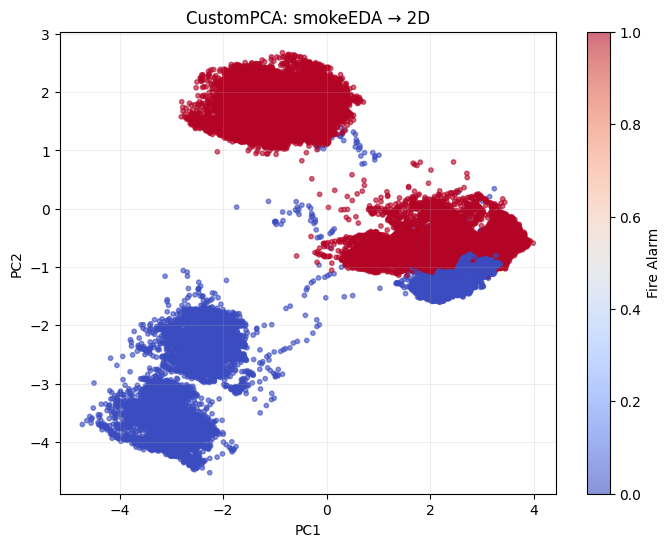

In [31]:
smoke = pd.read_csv("../data/smokeEDA.csv")
y = smoke["Fire Alarm"].to_numpy()
X = smoke.drop(columns=["Fire Alarm"])

prep = build_preprocessor(X)
X_p = prep.fit_transform(X)

pca2 = CustomPCA(n_components=2, scale=False)
X_2d = pca2.fit_transform(X_p)

print("Explained variance ratio:", pca2.explained_variance_ratio_)

plt.figure(figsize=(8,6))
plt.scatter(X_2d[:,0], X_2d[:,1], c=y, s=10, alpha=0.6, cmap="coolwarm")
plt.title("CustomPCA: smokeEDA → 2D")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(label="Fire Alarm")
plt.grid(True, alpha=0.2)
plt.show()

In [32]:
class CustomKMeans:
    def __init__(self, n_clusters=3, max_iter=300, random_state=42):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.random_state = random_state
        self.centroids = None
        self.wcss_ = 0
        self.labels_ = None
        
    def fit_predict(self, X):
        np.random.seed(self.random_state)
        random_idx = np.random.permutation(X.shape[0])[:self.n_clusters]
        self.centroids = X[random_idx]
        
        for i in range(self.max_iter):
            distances = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)
            
            labels = np.argmin(distances, axis=1)
            
            new_centroids = np.array([X[labels == k].mean(axis=0) if sum(labels == k) > 0 
                                      else self.centroids[k] for k in range(self.n_clusters)])
            
            if np.all(self.centroids == new_centroids):
                self.labels_ = labels
                break
            self.centroids = new_centroids
            self.labels_ = labels
            
        self.wcss_ = 0
        for k in range(self.n_clusters):
            cluster_points = X[self.labels_ == k]
            self.wcss_ += np.sum((cluster_points - self.centroids[k]) ** 2)
            
        return self.labels_

WCSS: 159441.8697834251
Centroids: [[ 2.33033224 -0.77298381]
 [-1.38315933  0.45880143]]


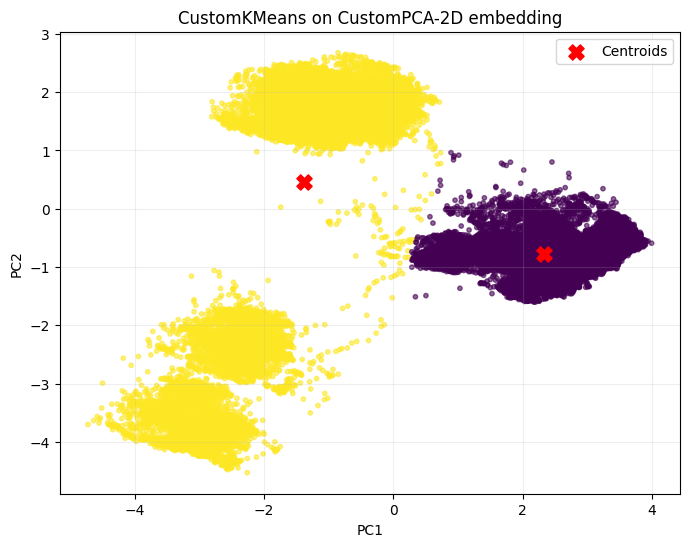

Fire Alarm  False  True 
Cluster                 
0            4866  11044
1            7121  19684

Purity per cluster:
 Cluster
0    0.694155
1    0.734341
Name: purity, dtype: float64

Weighted purity: 0.7193725857427133


In [33]:
kmeans = CustomKMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X_2d)

print("WCSS:", kmeans.wcss_)
print("Centroids:", kmeans.centroids)

plt.figure(figsize=(8,6))
plt.scatter(X_2d[:,0], X_2d[:,1], c=clusters, s=10, alpha=0.6, cmap="viridis")
plt.scatter(kmeans.centroids[:,0], kmeans.centroids[:,1], c="red", s=120, marker="X", label="Centroids")
plt.title("CustomKMeans on CustomPCA-2D embedding")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

ct = pd.crosstab(pd.Series(clusters, name="Cluster"), pd.Series(y, name="Fire Alarm"))
print(ct)

purity = (ct.max(axis=1) / ct.sum(axis=1)).rename("purity")
print("\nPurity per cluster:\n", purity)
print("\nWeighted purity:", (ct.max(axis=1).sum() / ct.to_numpy().sum()))